# Credit Card Fraud Detection - Neural Network Model
This notebook contains the implementation and evaluation of a Multilayer Perceptron (MLP) neural network. It explores algorithmic-level imbalance handling using custom Focal Loss, as well as a data-level comparison using SMOTE.

In [1]:
# Cell 1: Imports and Device Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Scikit-learn for evaluation and splitting
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc

sns.set_theme(style="whitegrid")

# Automatically detect if a GPU or Apple Silicon (MPS) is available
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using compute device: {device}")

Using compute device: mps


In [2]:
# Cell 2: Load Data, Scale, and Create Tensors
# 1. Load and scale identically to the baseline
df = pd.read_csv('creditcard.csv')

scaler = StandardScaler()
df['Scaled_Amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['Scaled_Time'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))

df.drop(['Time', 'Amount'], axis=1, inplace=True)
scaled_amount = df.pop('Scaled_Amount')
scaled_time = df.pop('Scaled_Time')
df.insert(0, 'Scaled_Time', scaled_time)
df.insert(1, 'Scaled_Amount', scaled_amount)

# 2. Extract features and target as NumPy arrays
X = df.drop('Class', axis=1).values
y = df['Class'].values

# 3. Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Convert NumPy arrays to PyTorch Tensors and send to device
X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.FloatTensor(y_train).view(-1, 1).to(device) # Reshape for PyTorch loss functions
X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.FloatTensor(y_test).view(-1, 1).to(device)

# 5. Create DataLoaders for Mini-Batch Gradient Descent
batch_size = 2048 # A larger batch size is efficient for tabular data
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Training tensors created. Shape: {X_train_tensor.shape}")
print(f"Test tensors created. Shape: {X_test_tensor.shape}")
print(f"Batches per epoch: {len(train_loader)}")

Training tensors created. Shape: torch.Size([227845, 30])
Test tensors created. Shape: torch.Size([56962, 30])
Batches per epoch: 112


In [3]:
# Cell 3: Define Neural Network Architecture
class FraudMLP(nn.Module):
    def __init__(self, input_size):
        super(FraudMLP, self).__init__()
        
        # A simple but effective architecture for tabular data
        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(0.2), # Drops 20% of neurons randomly to prevent overfitting
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
            # Note: We do NOT use a Sigmoid layer here at the end. 
            # We will output raw "logits" because PyTorch's loss functions 
            # handle the sigmoid activation internally for better numerical stability.
        )

    def forward(self, x):
        return self.network(x)

In [4]:
# Cell 4: Custom Focal Loss Implementation
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0):
        super(FocalLoss, self).__init__()
        # alpha > 0.5 heavily penalizes missing the minority class (Fraud)
        # gamma > 0 focuses the model on hard-to-classify examples
        self.alpha = alpha
        self.gamma = gamma
        # BCEWithLogitsLoss combines a Sigmoid layer and Binary Cross Entropy safely
        self.bce_with_logits = nn.BCEWithLogitsLoss(reduction='none')

    def forward(self, inputs, targets):
        # Calculate standard binary cross entropy
        bce_loss = self.bce_with_logits(inputs, targets)
        
        # Calculate the focal weight
        pt = torch.exp(-bce_loss) 
        focal_weight = self.alpha * (1 - pt)**self.gamma
        
        # Apply the weight to the loss
        focal_loss = focal_weight * bce_loss
        return focal_loss.mean()

In [5]:
# Cell 5: Initialization
input_dim = X_train_tensor.shape[1] # Grabs the 30 features from your tensor

# 1. Instantiate the model and send it to the GPU
mlp_model = FraudMLP(input_size=input_dim).to(device)

# 2. Instantiate our custom Focal Loss
criterion = FocalLoss(alpha=0.75, gamma=2.0)

# 3. Setup the Adam Optimizer
learning_rate = 0.001
optimizer = optim.Adam(mlp_model.parameters(), lr=learning_rate)

print(mlp_model)
print(f"Model sent to: {device}")

FraudMLP(
  (network): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)
Model sent to: mps


In [6]:
# Cell 6: Training Loop
epochs = 20

print("Starting training...")
for epoch in range(epochs):
    mlp_model.train() # Set the model to training mode
    total_loss = 0
    
    # Iterate through the mini-batches
    for batch_X, batch_y in train_loader:
        # 1. Zero the gradients
        optimizer.zero_grad()
        
        # 2. Forward pass: get predictions
        predictions = mlp_model(batch_X)
        
        # 3. Calculate Focal Loss
        loss = criterion(predictions, batch_y)
        
        # 4. Backward pass: calculate gradients
        loss.backward()
        
        # 5. Update weights
        optimizer.step()
        
        total_loss += loss.item()
        
    # Print average loss for the epoch
    avg_loss = total_loss / len(train_loader)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{epochs}] - Average Focal Loss: {avg_loss:.4f}")

print("Training complete!")

Starting training...
Epoch [1/20] - Average Focal Loss: 0.0210
Epoch [5/20] - Average Focal Loss: 0.0008
Epoch [10/20] - Average Focal Loss: 0.0007
Epoch [15/20] - Average Focal Loss: 0.0006
Epoch [20/20] - Average Focal Loss: 0.0005
Training complete!


Neural Network PR-AUC: 0.7785
Default 0.5 Threshold F1-Score: 0.8083
Optimal Threshold: 0.3943 (Yields F1-Score: 0.8317)


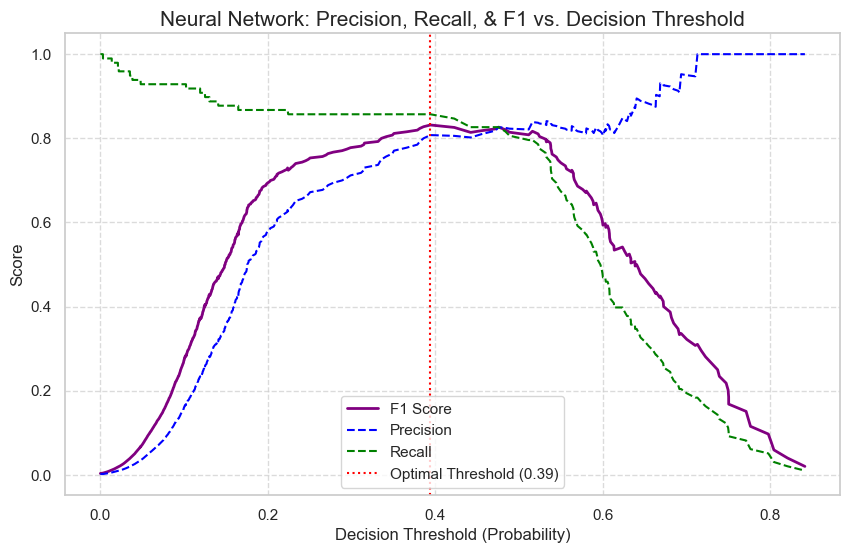

In [7]:
# Cell 7: Evaluation and Threshold Tuning
mlp_model.eval() # Set the model to evaluation mode (turns off Dropout)

# Get predictions on the test set without tracking gradients
with torch.no_grad():
    # Pass test data through model
    test_logits = mlp_model(X_test_tensor)
    
    # Apply sigmoid to get probabilities for the PR curve
    nn_probs = torch.sigmoid(test_logits).cpu().numpy().flatten()
    y_test_numpy = y_test_tensor.cpu().numpy().flatten()

# Calculate Precision, Recall, and PR-AUC
nn_precision, nn_recall, nn_thresholds = precision_recall_curve(y_test_numpy, nn_probs)
nn_pr_auc = auc(nn_recall, nn_precision)
print(f"Neural Network PR-AUC: {nn_pr_auc:.4f}")

# Threshold Tuning
# Slice arrays to match lengths
nn_f1_scores = 2 * (nn_precision[:-1] * nn_recall[:-1]) / (nn_precision[:-1] + nn_recall[:-1] + 1e-8) # added epsilon to avoid div by zero

# Find optimal threshold
nn_optimal_idx = np.argmax(nn_f1_scores)
nn_optimal_threshold = nn_thresholds[nn_optimal_idx]
nn_best_f1 = nn_f1_scores[nn_optimal_idx]

# Calculate F1 at default 0.5 threshold
nn_default_idx = np.searchsorted(nn_thresholds, 0.5)
nn_default_f1 = 2 * (nn_precision[nn_default_idx] * nn_recall[nn_default_idx]) / (nn_precision[nn_default_idx] + nn_recall[nn_default_idx] + 1e-8)

print(f"Default 0.5 Threshold F1-Score: {nn_default_f1:.4f}")
print(f"Optimal Threshold: {nn_optimal_threshold:.4f} (Yields F1-Score: {nn_best_f1:.4f})")

# Plotting the Trade-off
plt.figure(figsize=(10, 6))
plt.plot(nn_thresholds, nn_f1_scores, label='F1 Score', color='purple', lw=2)
plt.plot(nn_thresholds, nn_precision[:-1], label='Precision', color='blue', linestyle='--')
plt.plot(nn_thresholds, nn_recall[:-1], label='Recall', color='green', linestyle='--')

plt.axvline(x=nn_optimal_threshold, color='red', linestyle=':', 
            label=f'Optimal Threshold ({nn_optimal_threshold:.2f})')

plt.title('Neural Network: Precision, Recall, & F1 vs. Decision Threshold', fontsize=15)
plt.xlabel('Decision Threshold (Probability)', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.legend(loc='lower center')
plt.grid(True, linestyle='--', alpha=0.7)

plt.savefig('nn_threshold_tuning.png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
# Cell 8: Train Neural Network on SMOTE Data
from imblearn.over_sampling import SMOTE
import torch.nn as nn
import torch.optim as optim

print("Generating SMOTE data for Neural Network...")
# 1. Apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# 2. Convert to Tensors and create DataLoader
X_train_smote_tensor = torch.FloatTensor(X_train_smote).to(device)
y_train_smote_tensor = torch.FloatTensor(y_train_smote).view(-1, 1).to(device)

smote_train_dataset = TensorDataset(X_train_smote_tensor, y_train_smote_tensor)
smote_train_loader = DataLoader(smote_train_dataset, batch_size=batch_size, shuffle=True)

# 3. Initialize new model, standard BCE loss, and optimizer
smote_mlp_model = FraudMLP(input_size=input_dim).to(device)
smote_criterion = nn.BCEWithLogitsLoss() # Standard loss (no focal weighting)
smote_optimizer = optim.Adam(smote_mlp_model.parameters(), lr=0.001)

# 4. Training Loop
epochs = 20
print("Starting SMOTE NN training...")
for epoch in range(epochs):
    smote_mlp_model.train()
    total_loss = 0
    
    for batch_X, batch_y in smote_train_loader:
        smote_optimizer.zero_grad()
        predictions = smote_mlp_model(batch_X)
        loss = smote_criterion(predictions, batch_y)
        loss.backward()
        smote_optimizer.step()
        total_loss += loss.item()
        
    avg_loss = total_loss / len(smote_train_loader)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{epochs}] - Average BCE Loss: {avg_loss:.4f}")

print("SMOTE NN Training complete!")

Generating SMOTE data for Neural Network...
Starting SMOTE NN training...
Epoch [1/20] - Average BCE Loss: 0.1816
Epoch [5/20] - Average BCE Loss: 0.0149
Epoch [10/20] - Average BCE Loss: 0.0063
Epoch [15/20] - Average BCE Loss: 0.0038
Epoch [20/20] - Average BCE Loss: 0.0028
SMOTE NN Training complete!


In [9]:
# Cell 9: SMOTE NN Evaluation
smote_mlp_model.eval()

with torch.no_grad():
    smote_test_logits = smote_mlp_model(X_test_tensor)
    smote_nn_probs = torch.sigmoid(smote_test_logits).cpu().numpy().flatten()

# Calculate Precision, Recall, and PR-AUC
smote_nn_precision, smote_nn_recall, smote_nn_thresholds = precision_recall_curve(y_test_numpy, smote_nn_probs)
smote_nn_pr_auc = auc(smote_nn_recall, smote_nn_precision)
print(f"SMOTE Neural Network PR-AUC: {smote_nn_pr_auc:.4f}")

# Threshold Tuning
smote_nn_f1_scores = 2 * (smote_nn_precision[:-1] * smote_nn_recall[:-1]) / (smote_nn_precision[:-1] + smote_nn_recall[:-1] + 1e-8)

smote_nn_optimal_idx = np.argmax(smote_nn_f1_scores)
smote_nn_optimal_threshold = smote_nn_thresholds[smote_nn_optimal_idx]
smote_nn_best_f1 = smote_nn_f1_scores[smote_nn_optimal_idx]

smote_nn_default_idx = np.searchsorted(smote_nn_thresholds, 0.5)
smote_nn_default_f1 = 2 * (smote_nn_precision[smote_nn_default_idx] * smote_nn_recall[smote_nn_default_idx]) / (smote_nn_precision[smote_nn_default_idx] + smote_nn_recall[smote_nn_default_idx] + 1e-8)

print(f"Default 0.5 Threshold F1-Score: {smote_nn_default_f1:.4f}")
print(f"Optimal Threshold: {smote_nn_optimal_threshold:.4f} (Yields F1-Score: {smote_nn_best_f1:.4f})")

SMOTE Neural Network PR-AUC: 0.8026
Default 0.5 Threshold F1-Score: 0.6987
Optimal Threshold: 0.9980 (Yields F1-Score: 0.7978)


Ultimate Master PR-Curve generated and saved successfully!


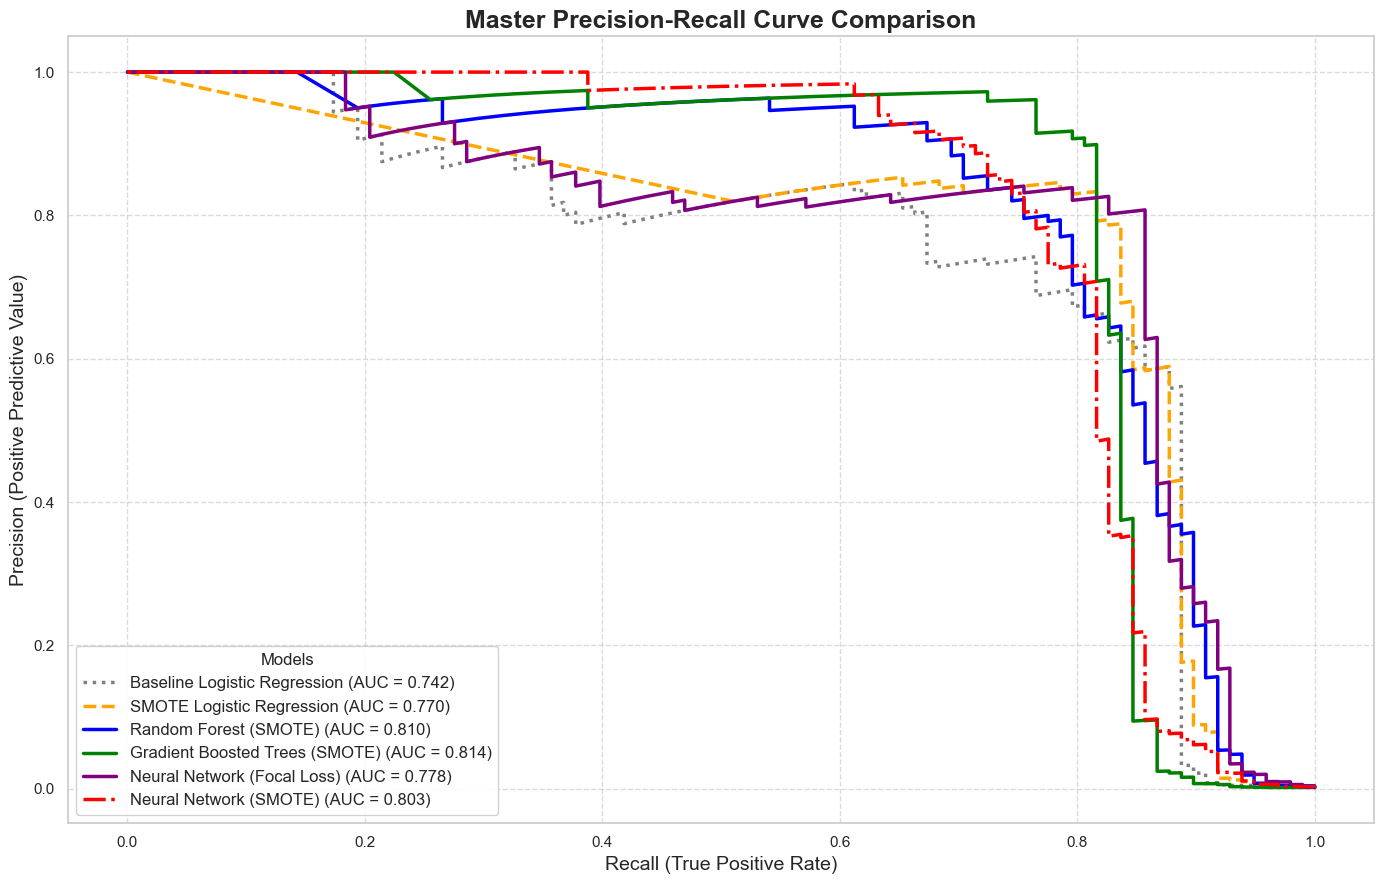

In [10]:
# Cell 10: The Master PR-Curve (All 6 Models)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

# 1. Load the data from the other notebooks
try:
    baseline_data = np.load('baseline_predictions.npz')
    tree_data = np.load('tree_predictions.npz')
    
    baseline_lr_probs = baseline_data['baseline_lr']
    smote_lr_probs = tree_data['smote_lr']
    rf_probs = tree_data['rf']
    gbt_probs = tree_data['gbt']
except FileNotFoundError:
    print("Error: Could not find the .npz files. Make sure you ran the export cells in your other notebooks!")

# 2. Compile all models into a dictionary
models = {
    'Baseline Logistic Regression': baseline_lr_probs,
    'SMOTE Logistic Regression': smote_lr_probs,
    'Random Forest (SMOTE)': rf_probs,
    'Gradient Boosted Trees (SMOTE)': gbt_probs,
    'Neural Network (Focal Loss)': nn_probs,
    'Neural Network (SMOTE)': smote_nn_probs
}

# 3. Plotting
plt.figure(figsize=(14, 9))
colors = ['gray', 'orange', 'blue', 'green', 'purple', 'red']
linestyles = [':', '--', '-', '-', '-', '-.']

for (name, probs), color, ls in zip(models.items(), colors, linestyles):
    precision, recall, _ = precision_recall_curve(y_test_numpy, probs)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f'{name} (AUC = {pr_auc:.3f})', color=color, linestyle=ls, lw=2.5)

# Formatting
plt.title('Master Precision-Recall Curve Comparison', fontsize=18, fontweight='bold')
plt.xlabel('Recall (True Positive Rate)', fontsize=14)
plt.ylabel('Precision (Positive Predictive Value)', fontsize=14)
plt.legend(loc='lower left', fontsize=12, framealpha=0.9, title="Models")
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('ultimate_master_pr_curve.png', dpi=300, bbox_inches='tight')
print("Ultimate Master PR-Curve generated and saved successfully!")
plt.show()